Created by Angelo Orletti Del Rey for its masters in psychiatry at Unifesp - SP - Brasil

It was based in our groups previeous works in cotical striatal connectivity in INPD data base of fmri

In [1]:
import numpy as np
import os, sys
import bids
import nibabel as nib
from scipy.stats import pearsonr
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import NegativeBinomial

import matplotlib.pyplot as plt

import argparse
import pandas as pd

from sklearn.preprocessing import StandardScaler

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# from scipy.linalg import LinAlgError

# Suppress convergence warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


In [2]:
def parse():

        options = argparse.ArgumentParser(description="Run 1st level analysis. Created by ...")
        options.add_argument('-p', '--participants', nargs='+',dest="participants", action='store', type=str, required=False,
                            help='id of subject or list of subjects')
        options.set_defaults(participants=None)
        options.add_argument('-w', '--workdir',dest="workdir", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(workdir=os.environ["ROOTDIR"])
        options.add_argument('-b', '--bidsdir',dest="rawdata", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(rawdata=os.path.join(os.environ["ROOTDIR"],"BIDS"))
        options.add_argument('-d', '--derivatives',dest="derivatives", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        options.add_argument('-o', '--outputs',dest="output", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        #print(options.parse_args())

        return options.parse_args()

os.environ["ROOTDIR"] = r'D://'   # seth path
rootdir = os.environ["ROOTDIR"]
if hasattr(sys, "ps1"):
    options = {}
    workdir = os.environ["ROOTDIR"]
    firstleveldir  = os.path.join(workdir,"BIDS","derivatives","first_level_results")
    demographic = os.path.join(workdir,"metadata")
    confounds = os.path.join(workdir,"metadata")
    output = os.path.join(workdir,'second_level_results')
    participants = []

else :
    options = parse()
    participants = options.participants
    workdir = options.workdir
    rawdata = options.rawdata
    derivat = options.derivatives
    output  = options.outputs

print('firstlevel: ', firstleveldir)
    
bidslayout = bids.BIDSLayout(firstleveldir, validate = False) #With validate = True it doesn't find any subjects

if not participants:
    participants = bidslayout.get_subjects() #take all subjects
    #participants_sub = ["sub-" + item for item in participants]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

tmap_allsubj = [] #initialize array for tmaps

print("Loading tmaps for all participants...")
for p in participants:
    #print(f"Subject: {p}")
    p = p.replace("sub-", "")

    # for ses in bidslayout.get_sessions(subject=p):
    #     #print(f"Session: {ses}")                
    
    ses = '1'

    for r in bidslayout.get_runs(subject=p, session=ses):
        #print(f"Run: {r}")

        tmap_metadata = {
            'task': 'rest',
            'suffix': 'tstat',
            'extension': '.txt',
            'run': str(r),
            'session': str(ses),
            'subject': 'sub-'+p,
            'space': 'MNI152NLin2009cAsym',
            'seed': 'SeedtoROI'
        }

        # Save each tmap as a nifti file
        filepath = os.path.join(firstleveldir,tmap_metadata["subject"],"ses-"+tmap_metadata['session'],"func")
        filename = tmap_metadata["subject"] + "_" + \
                    "ses-"+tmap_metadata['session'] + "_" + \
                    "task-"+tmap_metadata['task'] + "_" + \
                    "run-"+tmap_metadata['run'] + "_" + \
                    "space-"+tmap_metadata['space'] + "_" + \
                    "seed-"+tmap_metadata['seed'] + "_" + \
                    tmap_metadata["suffix"] + \
                    tmap_metadata["extension"]
        tmap_path = os.path.join(filepath, filename)

        #load the tmaps for each subject and then append to the tmap_allsubj array
        tmap = pd.read_csv(tmap_path, delimiter=' ', header=None, skiprows=1) #also skips the first row
        tmap.columns = seednames
        tmap_allsubj.append(tmap)

#load socioeconomic and psichometric data for all subjects
print("Loading socioeconomic and psichometric data for all participants...")
socio_psi=pd.read_csv(os.path.join(demographic,'variaveis_analise_conf_nova-exclusão.tsv'), sep='\t')
#substitute in age colunm , to . for decimals if necessary and convert to float
# socio_psi['age'] = socio_psi['age'].str.replace(',', '.').astype(float)

# organinzing the tmaps. Joining the columns of the tmaps for all subjects. So for each subject
# we have to join the first collunm of the first tmap with the first column of the second tmap and so on
# and then join the second column of the first tmap with the second column of the second tmap and so on
# and so on
print("Organizing tmaps...")
tmap_allsubj = pd.concat(tmap_allsubj, axis=1)
tmap_allsubj_organized = {}

for seed in seednames:
    #drop columns with names different from seednames[i]
    tmap_allsubj_organized[seed] = tmap_allsubj.drop(columns=[col for col in tmap_allsubj.columns if col != seed])

# What do we have now: tmap_allsubj_organized is a dictionary with keys being the seednames and values being
# dataframes with the tmaps for all subjects for that seed. This have dimensions of n_ROIs x n_subjects
# Now we have to transpose it to get the data in the format n_subjects x n_ROIs and then join with the
# socioeconomic and psichometric data
# Also, we have to add the sub_id column to the conectivity data to be able to join with the socioeconomic
# and psichometric data
subs = {'sub_id': []}
for p in participants:
    ses = '1'
    if bidslayout.get_runs(subject=p, session=ses) != []:
        subs['sub_id'].append('sub-'+p)

subs = pd.DataFrame(subs)

# create the collunms names for the data frame of rois
roi_names = [f'roi_{i}' for i in range(101)]

for seed in seednames:
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].transpose()
    tmap_allsubj_organized[seed].columns = roi_names
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].reset_index().join(subs, how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['index'])

# Now we have to join the tmaps with the socioeconomic and psichometric data
print("Joining tmaps with socioeconomic and psichometric data...")

for seed in seednames:
    tmap_allsubj_organized[seed] = pd.merge(tmap_allsubj_organized[seed], socio_psi, on='sub_id', how='inner')
    # scaling the data for the regression for the continous variables age, abepscore, cape
    # and for the rois
    # Scale all ROIs
    roi_cols = [f'roi_{i}' for i in range(101)]
    scaler_roi = StandardScaler()
    tmap_allsubj_organized[seed][roi_cols] = scaler_roi.fit_transform(tmap_allsubj_organized[seed][roi_cols])
    
    # Scale age and abepscore together
    scaler_demo = StandardScaler()
    tmap_allsubj_organized[seed][['age', 'abepscore']] = scaler_demo.fit_transform(tmap_allsubj_organized[seed][['age', 'abepscore']])
    


firstlevel:  D://BIDS\derivatives\first_level_results
Loading tmaps for all participants...
Loading socioeconomic and psichometric data for all participants...
Organizing tmaps...
Joining tmaps with socioeconomic and psichometric data...


In [3]:
# plt.hist(tmap_allsubj_organized['DCPutamen']['cape_tot'])

In [4]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confound variables
print("Running regression analysis (salience and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# selecting only the rois that belong to the salience network (name with SalVentAttn) 
# or the default mode network (name with Default)
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default')]
print("Selected ROIs for analysis:", shaeffer_network['index'].tolist())
print("There are", len(shaeffer_network['index'].tolist()), "rois in the salience and default mode network that will be analyzed")

# running the regression analysis for each roi in the salience network
results_networks = {} 
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            #building my strign for the fomrula
            formula = f'{cape} ~ roi_{roi} + age + C(selection) + C(gender) + abepscore + C(colection_site) + fd_mean_value'
            
            #running the regression analysis
            # model = smf.glm(formula, data=tmap_allsubj_organized[seed],
            #                         family=NegativeBinomial())
            model = smf.ols(formula, data=tmap_allsubj_organized[seed])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                # 'deviance': fit.deviance,
                'R_squared_ajusted': fit.rsquared_adj,
                # 'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid,
                # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }

Running regression analysis (salience and default mode network)...
Selected ROIs for analysis: [24, 25, 26, 27, 28, 29, 30, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 74, 75, 76, 77, 78, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
There are  36  rois in the salience and default mode network that will be analyzed


In [29]:
# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    print(f'Intra CAPE FDR - {cape}')
    
    pvals = []
    keys = []  # <- guardar correspondência
    
    # coletar p-values + chaves
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            pvals.append(results_networks[cape][seed][roi]['p_value'])
            keys.append((seed, roi))
    
    print(f'Number of p-values to correct for {cape}: {len(pvals)}')

    # correção FDR
    corrected = multipletests(pvals, method='fdr_bh')[1]

    # reatribuir corretamente
    for (seed, roi), corr_p in zip(keys, corrected):
        results_networks[cape][seed][roi]['corr_p_value_within_cape'] = corr_p

        if corr_p <= 0.05:
            print(f"###{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} -> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

        if corr_p <= 0.27:
            print(f">>>{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} -> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

# correcting p-values for all CAPE scores together
# creating a list with all p-values for all CAPE scores to correct them together
all_p_values = [results_networks[cape][seed][roi]['p_value']
                 for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']
                 for seed in seednames
                 for roi in results_networks[cape][seed].keys()]

# Correct the p-values for all CAPE scores together
corrected_p_values_all = multipletests(all_p_values, method='fdr_bh')[1]
# printing the ones that are significant after correcting for all CAPE scores together
print(f'General FDR - All CAPE scores together')
index = 0
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            results_networks[cape][seed][roi]['corr_p_value_general'] = corrected_p_values_all[index]
            index += 1

            if results_networks[cape][seed][roi]['corr_p_value_general'] <= 0.05:
                print(f"###{cape} roi-{roi} -> corr_p_val_general {results_networks[cape][seed][roi]['corr_p_value_general']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} -> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

print('No FDR Corretion')
# printing the ones that are significant without correcting for all CAPE scores together
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            if results_networks[cape][seed][roi]['p_value'] <= 0.005:
                print(f"### {cape} roi-{roi} -> p_val {results_networks[cape][seed][roi]['p_value']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} -> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

#printing the top five highest associations for each CAPE score without correcting for all CAPE scores together
print('---Top 5 associations for each CAPE score without general FDR correction---')
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    associations = []
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            associations.append((results_networks[cape][seed][roi]['coef'], cape, seed, roi, results_networks[cape][seed][roi]['p_value'], results_networks[cape][seed][roi]['t_value'], results_networks[cape][seed][roi]['R_squared_ajusted'], results_networks[cape][seed][roi]['corr_p_value_general'], results_networks[cape][seed][roi]['corr_p_value_within_cape']))
    # Sort the associations by absolute value of the coefficient and get the top 5
    top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
    print(f"Top 5 associations for {cape}:")
    for assoc in top_associations:
        print(f"### {assoc[1]} seed-{assoc[2]} roi-{assoc[3]} -> coef {assoc[0]:.3f} -> p_val {assoc[4]:.3f} -> t-value {assoc[5]:.3f} -> R2 ajustado {assoc[6]:.3f} -> corr_p_val_general {assoc[7]:.3f} -> corr_p_val_within_cape {assoc[8]:.3f} ")


Intra CAPE FDR - cape_tot
Number of p-values to correct for cape_tot: 216
>>>cape_tot seed-DRPutamen roi-44 -> corr_p_val_within_cape 0.062 -> Association -0.891 -> t-value -3.658 -> R2 ajustado 0.121
Intra CAPE FDR - cape_PA_score
Number of p-values to correct for cape_PA_score: 216
Intra CAPE FDR - cape_PI_score
Number of p-values to correct for cape_PI_score: 216
Intra CAPE FDR - cape_BE_score
Number of p-values to correct for cape_BE_score: 216
General FDR - All CAPE scores together
No FDR Corretion
### cape_tot roi-44 -> p_val 0.000 -> Association -0.891 -> t-value -3.658 -> R2 ajustado 0.121 
### cape_tot roi-98 -> p_val 0.003 -> Association -0.742 -> t-value -3.033 -> R2 ajustado 0.112 
### cape_PA_score roi-98 -> p_val 0.003 -> Association -0.183 -> t-value -2.986 -> R2 ajustado 0.065 
### cape_PA_score roi-44 -> p_val 0.004 -> Association -0.175 -> t-value -2.908 -> R2 ajustado 0.064 
### cape_PI_score roi-50 -> p_val 0.005 -> Association 0.280 -> t-value 2.842 -> R2 ajustado 

In [6]:
# Merge all regression parameters into a single dataframe grouped by CAPE and seed
all_results = []

for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    # Process salience network results
    for seed in seednames:
        for network in ['SalVentAttn', 'Default']:
            for roi in shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']:
                # Get the result values as a dictionary
                result_dict = results_networks[cape][seed][roi].to_dict('records')[0] if isinstance(results_networks[cape][seed][roi], pd.DataFrame) else results_networks[cape][seed][roi]
                # Add metadata columns
                result_dict['CAPE'] = cape
                result_dict['seed'] = seed
                result_dict['network'] = network
                result_dict['ROI'] = roi
                all_results.append(result_dict)
    

# Create dataframe from list of dictionaries
merged_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = ['CAPE', 'seed', 'network', 'ROI', 'coef', 'intercept', 't_value', 'p_value', 
                'corr_p_value_general', 'corr_p_value_within_cape', 'AIC', 'BIC',
                'R_squared_ajusted', 'residuals', 'log_likelihood']
                #'deviance','degrees_of_freedom' ,'mcFadden_R_squared',
merged_df = merged_df[column_order]

# Save to CSV
merged_df.to_csv(os.path.join(output, 'results_2ndlvl_OLS.csv'), index=False)

print(f"Merged dataframe saved to: {os.path.join(output, 'results_2ndlvl_OLS.csv')}")
print(f"Shape: {merged_df.shape}")
# print(f"\nFirst few rows:")
# print(merged_df.head(10))

Merged dataframe saved to: D://second_level_results\results_2ndlvl_OLS.csv
Shape: (864, 15)


In [7]:
# save the t_map_allsubj_organized for each seed as a csv file
for seed in seednames:
    tmap_allsubj_organized[seed].to_csv(os.path.join(output, f'tmap_allsubj_organized_{seed}.csv'),
                                         index=False)
print(f"Tmaps saved to CSV files in the output directory {output}.")

Tmaps saved to CSV files in the output directory D://second_level_results.


Text(0, 0.5, 'Residual Value')

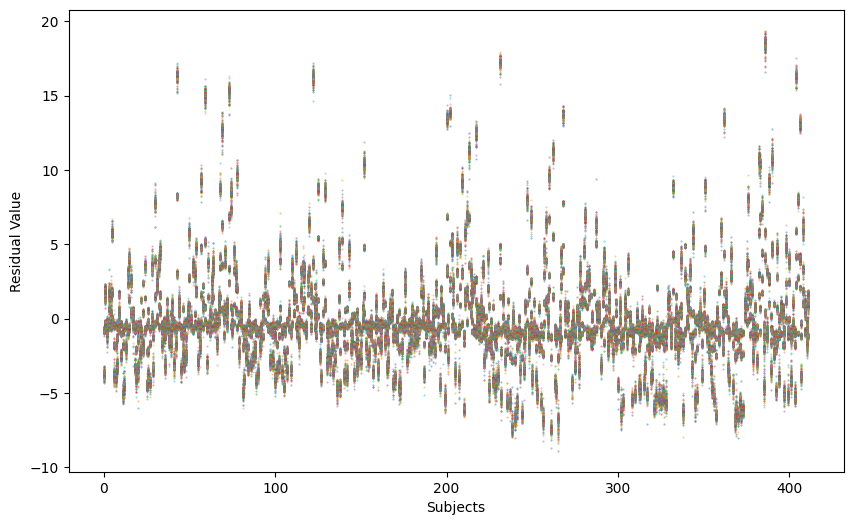

In [8]:
# plot a summary of the residuals distribution
# merged_df['residuals'][0] #= merged_df['residuals'].apply(lambda x: np.mean(x) if isinstance(x, np.ndarray) else x)
plt.figure(figsize=(10, 6))
for array in merged_df['residuals'].values:
    plt.plot(array, alpha=0.5, marker='o', linestyle='None', markersize=0.5)
# plt.title('Distribution of Residuals')
plt.xlabel('Subjects')
plt.ylabel('Residual Value')


Text(0.5, 0, 'Residuals')

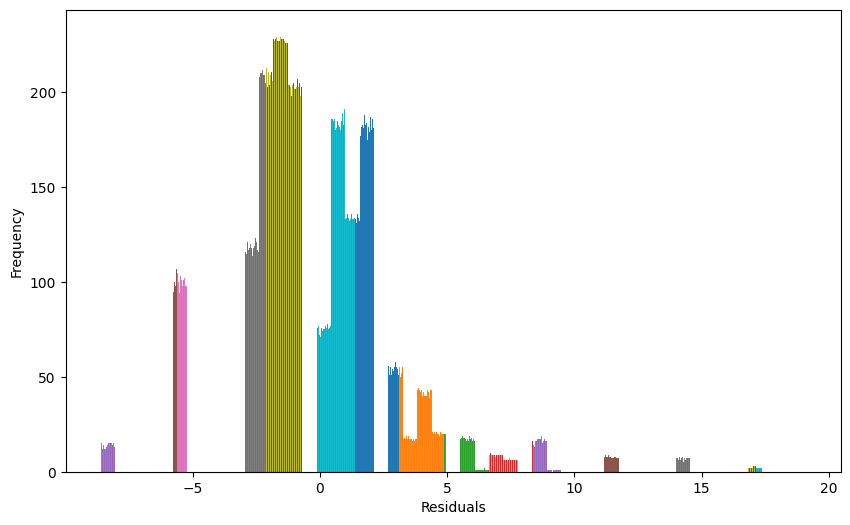

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(merged_df['residuals'])
plt.ylabel('Frequency')
plt.xlabel('Residuals')
#write mean skewness and kurtosis in the plot
# mean_skewness = merged_df['residuals'].apply(lambda x: pd.Series(x).skew() if isinstance(x, np.ndarray) else np.nan).mean()
# mean_kurtosis = merged_df['residuals'].apply(lambda x: pd.Series(x).kurtosis() if isinstance(x, np.ndarray) else np.nan).mean()
# # put it to a note on the top left
# plt.text(0.05, 0.95, f'Mean Skewness: {mean_skewness:.2f}\nMean Kurtosis: {mean_kurtosis:.2f}', transform=plt.gca().transAxes, verticalalignment='top')
# plt.title('Distribution of Residuals')

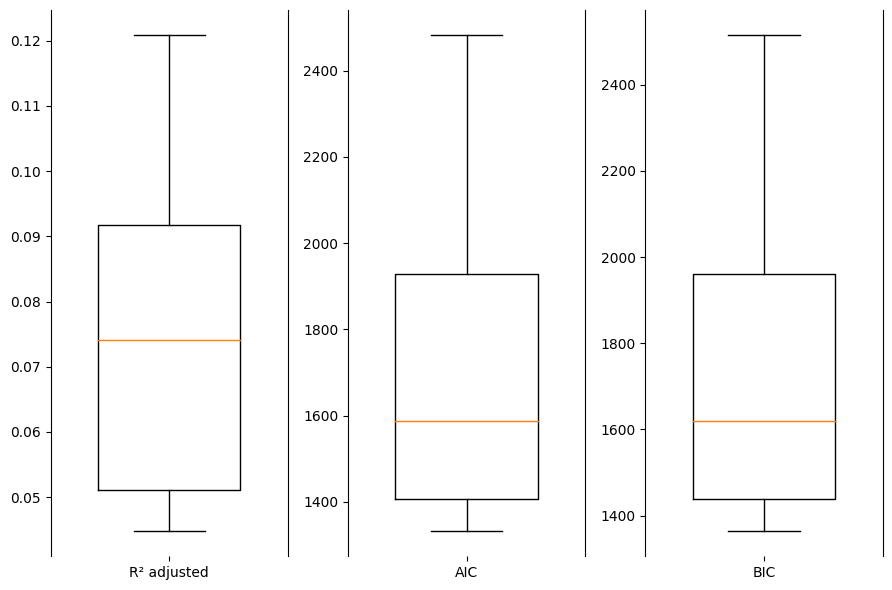

In [10]:

# fig, ax = plt.subplots(figsize=(8,5))

metrics = [
    merged_df['R_squared_ajusted'],
    # merged_df['deviance'] / merged_df['degrees_of_freedom'],
    merged_df['AIC'],
    merged_df['BIC']
]

labels = ['R² adjusted', 'AIC', 'BIC']

plt.figure(figsize=(12, 6))

#create 4 subplots for each metric
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    plt.boxplot(metric, positions=[i], widths=0.6)
    plt.xticks([i], [labels[i]])

    plt.gca().spines['top'].set_visible(False)  # Hide the top spine
    # plt.gca().spines['right'].set_visible(False)  # Hide the right spine
    # plt.gca().spines['left'].set_visible(False)  # Hide the left spine
    plt.gca().spines['bottom'].set_visible(False)  # Hide the bottom spine

plt.tight_layout()


In [11]:
#Across the 400 fitted negative binomial models, median McFadden’s R² was 0.041 (IQR: 0.032–0.055), median deviance/df was 1.07 (IQR: 0.98–1.15), indicating adequate model fit. AIC values ranged from XXXX to XXXX
# median_r2 = merged_df['mcFadden_R_squared'].median()
# print(f"Median McFadden's R²: {median_r2:.3f} (IQR: {merged_df['mcFadden_R_squared'].quantile(0.25):.3f} - {merged_df['mcFadden_R_squared'].quantile(0.75):.3f})")
# median_deviance_df = (merged_df['deviance'] / merged_df['degrees_of_freedom']).median()
# print(f"Median Deviance/df: {median_deviance_df:.2f} (IQR: {(merged_df['deviance'] / merged_df['degrees_of_freedom']).quantile(0.25):.2f} - {(merged_df['deviance'] / merged_df['degrees_of_freedom']).quantile(0.75):.2f})")
print(f"AIC values ranged from {merged_df['AIC'].min():.2f} to {merged_df['AIC'].max():.2f}")
print(f"BIC values ranged from {merged_df['BIC'].min():.2f} to {merged_df['BIC'].max():.2f}")

AIC values ranged from 1331.13 to 2483.34
BIC values ranged from 1363.30 to 2515.50
